# **En las 5 mejores ligas del mundo, como podemos detectar futuros maximos goleadores o asistentes?**

La identificación de talento joven o el descubrir jugadores que rinden mejor de lo que parece es un tema de profundo interes en el deporte, nos vamos a especificar en el futbol.
Este proyecto va a desarrollar un proyecto de machine learning que busque esos jugadores, analizando a los máximos goleadores y asistentes de la temporada como ejemplo, y que esos patrones que nos den van a servirnos de ayuda para lograr llevar a cabo el proyecto. Usamos un dataset que contiene datos de la temporada 2022-2023

Preguntas de Interes:
* Qué factores llevan a un delantero a ser goleador?
  * Qué tanto influye su calidad a la hora de hacer goles?
  * Suerte? buenos asistidores? gran rematador?
* Qué capacidades tienen los mayores asistentes?
  * Tienen denominadores comunes entre si?
* Hay grandes jugadores que por falta de un buen delantero no pueden tener las asistencias deseadas?
  * Hay grandes delanteros que no tienen a un buen asistidor y no pueden destacar?


Este Proyecto esta dirigido a:
- Clubes de Futbol: que busquen mejorar sus posibilades de reforzarse mejor de cara a un futuro, ya sea inmediato o lejano. Para que logren ver que es en lo que se tienen que fijar a la hora de ver a un buen prospecto de goleador/asistente
- Periodistas/ Data Sciencist: que quieran ver o usar estos gráficos para presentar o estudiarlos.
- Equipos de trabajo: especializados en los datos deportivos que quieran mejorar sus aptitudes a futuro.

Contexto Comercial:
Muchos clubes de futbol quiebran o estan en malas situaciones financieras por culpa de malas desiciones de fichajes o poca visión en los futuros jugadores de sus canteras. Cada vez más se empiezan a usar en el mundo del futbol los datos, y es por eso que este proyecto viene a generar soluciones a este gran problema, no solo económico, sino futbolístico, que lleva a grandes clubes a fracasos, pero que a su vez puede llevar a clubes con pocos recursos a generar grandes resultados.

Objetivo: Identificar a los futuros máximos goleadores y asistentes, y clasificarlos en diferentes niveles.

## Condiciones:

* Mínimo 15 partidos jugados
* Mínimo 1000 minutos jugados
* Se Mide todo sobre 90 minutos, para poder saber que jugadores son mas eficientes y quienes no.

Dataset:

In [1]:
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
from googleapiclient.discovery import build
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
from google.colab import files

# 1. Subir el kaggle.json si no está
files.upload()

# 2. Configurar API y Descargar
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d vivovinco/20222023-football-player-stats
!unzip -o 20222023-football-player-stats.zip

# 3. CARGA DE RAÍZ CON EL ENCODING CORRECTO
df = pd.read_csv('2022-2023 Football Player Stats.csv',
                 sep=';',
                 encoding='latin1')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vivovinco/20222023-football-player-stats
License(s): Attribution 4.0 International (CC BY 4.0)
100% 470k/470k [00:00<00:00, 97.4MB/s]

Archive:  20222023-football-player-stats.zip
  inflating: 2022-2023 Football Player Stats.csv  


In [3]:
# Leemos el archivo descomprimido
df = pd.read_csv('2022-2023 Football Player Stats.csv', encoding='latin1', sep=';')

df

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,...,0.17,2.54,0.51,0.0,0.0,0.00,4.86,0.34,1.19,22.2
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,1987,22,22,...,0.05,0.18,1.59,0.0,0.0,0.00,6.64,2.18,1.23,64.0
2,3,Himad Abdelli,FRA,MFFW,Angers,Ligue 1,23,1999,14,8,...,0.00,1.05,1.40,0.0,0.0,0.00,8.14,0.93,1.05,47.1
3,4,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,...,0.00,0.35,0.80,0.0,0.0,0.05,6.60,0.50,0.50,50.0
4,5,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,...,0.00,0.23,2.02,0.0,0.0,0.00,6.51,0.31,0.39,44.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2684,2685,Szymon ?urkowski,POL,MF,Fiorentina,Serie A,25,1997,2,0,...,0.00,2.50,0.00,0.0,0.0,0.00,5.00,2.50,2.50,50.0
2685,2686,Szymon ?urkowski,POL,MF,Spezia,Serie A,25,1997,1,0,...,0.00,0.00,0.00,0.0,0.0,0.00,30.00,0.00,0.00,0.0
2686,2687,Martin Ødegaard,NOR,MF,Arsenal,Premier League,24,1998,20,20,...,0.05,2.51,0.70,0.0,0.0,0.00,5.19,0.48,0.70,40.9
2687,2688,Milan ?uri?,BIH,FW,Hellas Verona,Serie A,32,1990,16,7,...,0.38,0.00,0.13,0.0,0.0,0.00,2.05,14.50,3.59,80.1


In [4]:
# Aplicamos los filtros de 'Barrera Inicial'
# Usamos & para que se cumplan AMBAS condiciones
df = df[(df['MP'] >= 15) & (df['Min'] >= 1000)].copy()

In [5]:
df

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,...,0.17,2.54,0.51,0.0,0.0,0.00,4.86,0.34,1.19,22.2
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,1987,22,22,...,0.05,0.18,1.59,0.0,0.0,0.00,6.64,2.18,1.23,64.0
3,4,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,...,0.00,0.35,0.80,0.0,0.0,0.05,6.60,0.50,0.50,50.0
4,5,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,...,0.00,0.23,2.02,0.0,0.0,0.00,6.51,0.31,0.39,44.4
9,10,Zakaria Aboukhlal,MAR,FWMF,Toulouse,Ligue 1,22,2000,22,17,...,0.72,0.96,0.72,0.0,0.0,0.00,4.43,0.42,1.32,24.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2680,2681,Kurt Zouma,FRA,DF,West Ham,Premier League,28,1994,15,15,...,0.00,0.00,0.14,0.0,0.0,0.00,3.94,2.61,0.35,88.1
2682,2683,Igor Zubeldia,ESP,DF,Real Sociedad,La Liga,25,1997,16,14,...,0.00,0.21,0.86,0.0,0.0,0.00,4.93,2.00,1.57,56.0
2683,2684,Martín Zubimendi,ESP,MF,Real Sociedad,La Liga,24,1999,19,18,...,0.06,0.11,1.07,0.0,0.0,0.00,6.18,2.19,0.90,70.9
2686,2687,Martin Ødegaard,NOR,MF,Arsenal,Premier League,24,1998,20,20,...,0.05,2.51,0.70,0.0,0.0,0.00,5.19,0.48,0.70,40.9


In [6]:
# 1. Vamos a eliminar a los defensores y arqueros porque nos van a generar valores bajos innecesarios, sus posiciones no tienen como finalidad ni asistir ni marcar el gol.
posiciones_a_quitar = ['GK', 'DF']

# 2. Filtramos el DataFrame para quedarnos con todo lo que NO esté en esa lista
# El símbolo ~ significa "NOT" (no está en...)
df = df[~df['Pos'].isin(posiciones_a_quitar)].copy()

# 3. Verificación de las posiciones restantes
print("Posiciones que quedaron en el análisis:")
print(df['Pos'].unique())

# 4. Ver cuántos jugadores quedan para el modelo
print(f"\nTotal de jugadores (Mediocampistas y Delanteros): {len(df)}")

Posiciones que quedaron en el análisis:
['MFFW' 'MF' 'FWMF' 'FW' 'DFFW' 'DFMF' 'MFDF' 'FWDF']

Total de jugadores (Mediocampistas y Delanteros): 503


In [7]:
# Definimos las columnas que VAMOS A MANTENER, ya que había varias columnas que no sumaban nada, nos vamos a quedar con las siguientes:
columnas_mantener = [
    # Identificación y tiempo
    'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min',

    # GOLES Y REMATES
    'Goals', 'Shots', 'SoT', 'SoT%', 'G/Sh', 'G/SoT', 'ShoDist', 'ShoFK', 'ShoPK', 'PKatt',

    # PASES (Todas las métricas de Pases)
    'PasTotCmp', 'PasTotAtt', 'PasTotCmp%', 'PasTotDist', 'PasTotPrgDist',
    'PasShoCmp', 'PasShoAtt', 'PasShoCmp%', 'PasMedCmp', 'PasMedAtt', 'PasMedCmp%',
    'PasLonCmp', 'PasLonAtt', 'PasLonCmp%', 'Assists', 'PasAss', 'Pas3rd', 'PPA',
    'CrsPA', 'PasProg', 'PasAtt', 'PasLive', 'PasDead', 'PasFK', 'TB', 'Sw', 'PasCrs',
    'TI', 'CK', 'CkIn', 'CkOut', 'CkStr', 'PasCmp', 'PasOff',

    # CREACIÓN (SCA y GCA)
    'SCA', 'ScaPassLive', 'ScaPassDead', 'ScaDrib', 'ScaSh', 'ScaFld', 'ScaDef',
    'GCA', 'GcaPassLive', 'GcaPassDead', 'GcaDrib', 'GcaSh', 'GcaFld', 'GcaDef',

    # TOQUES Y CONDUCCIONES (Ofensivas)
    'Touches', 'TouMid3rd', 'TouAtt3rd', 'TouAttPen', 'TouLive',
    'ToAtt', 'ToSuc', 'ToSuc%', 'Carries', 'CarTotDist', 'CarPrgDist',
    'CarProg', 'Car3rd', 'CPA', 'Rec', 'RecProg'
]

# Filtramos el DataFrame para que solo queden estas
df = df[df.columns.intersection(columnas_mantener)].copy()

df

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,ToSuc,ToSuc%,Carries,CarTotDist,CarPrgDist,CarProg,Car3rd,CPA,Rec,RecProg
0,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,1596,...,1.19,31.8,26.7,136.1,56.6,1.53,1.07,0.40,30.2,5.65
3,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,1799,...,0.70,56.0,61.0,316.9,117.5,1.25,1.95,0.15,56.5,1.70
4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,1165,...,0.54,58.3,41.0,174.3,72.7,0.47,0.93,0.00,36.4,0.47
9,Zakaria Aboukhlal,MAR,FWMF,Toulouse,Ligue 1,22,2000,22,17,1507,...,1.02,32.1,28.6,177.7,74.7,3.05,1.08,1.14,27.1,9.52
10,Tammy Abraham,ENG,FW,Roma,Serie A,25,1997,22,18,1582,...,0.80,26.4,16.8,89.8,35.9,1.42,0.97,0.63,24.5,5.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2671,Piotr Zieli?ski,POL,MF,Napoli,Serie A,28,1994,21,16,1314,...,0.68,27.8,40.5,199.5,93.9,2.47,2.88,0.48,51.1,4.79
2677,Simon Zoller,GER,FW,Bochum,Bundesliga,31,1991,18,16,1214,...,0.00,0.0,12.9,44.0,14.7,0.52,0.07,0.37,17.4,3.93
2683,Martín Zubimendi,ESP,MF,Real Sociedad,La Liga,24,1999,19,18,1601,...,0.22,40.0,37.1,192.3,107.8,1.12,0.73,0.06,42.5,0.62
2686,Martin Ødegaard,NOR,MF,Arsenal,Premier League,24,1998,20,20,1684,...,1.28,57.1,33.0,183.0,83.9,2.78,1.71,0.96,40.5,5.08


Tenemos que pasar a medir sobre 90 minutos todas las estadisticas para poder ver con exactitud que jugadores usan mejores sus minutos.

In [8]:
# 1. Calculamos la métrica base: los "Partidos Completos" (90s)
# Esto es fundamental para dividir el resto de las estadísticas
df['90s'] = df['Min'] / 90

# 2. Definimos qué columnas NO se tocan
cols_no_tocar = [
    # Identificación y tiempo
    'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s',

    # Porcentajes y promedios (ya son tasas, dividirlos por 90 los arruinaría)
    'SoT%', 'G/Sh', 'G/SoT', 'ShoDist',
    'PasTotCmp%', 'PasShoCmp%', 'PasMedCmp%', 'PasLonCmp%', 'ToSuc%',

    # Pelota parada, penales y laterales (cantidades absolutas que pediste mantener)
    'ShoFK', 'ShoPK', 'PKatt', 'PasFK', 'PasDead', 'ScaPassDead', 'GcaPassDead',
    'CK', 'CkIn', 'CkOut', 'CkStr', 'TI'
]

# 3. Detectamos automáticamente qué columnas SÍ hay que normalizar
# Tomamos todas las columnas que te quedaste y le restamos las que no queremos tocar
cols_a_normalizar = [col for col in df.columns if col not in cols_no_tocar]

# 4. Aplicamos la división por 90
for col in cols_a_normalizar:
    # Usamos np.where para evitar errores de división por cero si un jugador tiene 0 minutos
    # Acá podés elegir sobreescribir la columna original (df[col] = ...)
    # o crear una nueva con el sufijo '_90'. Te recomiendo crear una nueva para no perder el crudo.
    df[f'{col}_90'] = np.where(df['90s'] > 0, df[col] / df['90s'], 0)

df

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,ToAtt_90,ToSuc_90,Carries_90,CarTotDist_90,CarPrgDist_90,CarProg_90,Car3rd_90,CPA_90,Rec_90,RecProg_90
0,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,1596,...,0.210338,0.067105,1.505639,7.674812,3.191729,0.086278,0.060338,0.022556,1.703008,0.318609
3,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,1799,...,0.062535,0.035019,3.051695,15.853808,5.878266,0.062535,0.097554,0.007504,2.826570,0.085047
4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,1165,...,0.071845,0.041717,3.167382,13.465236,5.616309,0.036309,0.071845,0.000000,2.812017,0.036309
9,Zakaria Aboukhlal,MAR,FWMF,Toulouse,Ligue 1,22,2000,22,17,1507,...,0.189317,0.060916,1.708029,10.612475,4.461181,0.182150,0.064499,0.068082,1.618447,0.568547
10,Tammy Abraham,ENG,FW,Roma,Serie A,25,1997,22,18,1582,...,0.171239,0.045512,0.955752,5.108723,2.042351,0.080784,0.055183,0.035841,1.393805,0.284450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2671,Piotr Zieli?ski,POL,MF,Napoli,Serie A,28,1994,21,16,1314,...,0.169178,0.046575,2.773973,13.664384,6.431507,0.169178,0.197260,0.032877,3.500000,0.328082
2677,Simon Zoller,GER,FW,Bochum,Bundesliga,31,1991,18,16,1214,...,0.027430,0.000000,0.956343,3.261944,1.089786,0.038550,0.005189,0.027430,1.289951,0.291351
2683,Martín Zubimendi,ESP,MF,Real Sociedad,La Liga,24,1999,19,18,1601,...,0.031480,0.012367,2.085572,10.810119,6.059963,0.062961,0.041037,0.003373,2.389132,0.034853
2686,Martin Ødegaard,NOR,MF,Arsenal,Premier League,24,1998,20,20,1684,...,0.120249,0.068409,1.763658,9.780285,4.483967,0.148575,0.091390,0.051306,2.164489,0.271496


 ## Vamos a explicar ahora si las columnnas que quedaron para mejor comprension de todos:

* Identificación y Tiempo

Player: Nombre del jugador.

Nation: Nacionalidad.

Pos: Posición.

Squad: Equipo.

Comp: Liga.

Age: Edad.

Born: Año de nacimiento.

MP: Partidos jugados.

Starts: Partidos como titular.

Min: Minutos jugados.

* Goles y Remates

Goals_90: Goles.

Shots_90: Remates totales.

SoT_90: Remates al arco.

SoT%: Porcentaje de remates que van al arco.

G/Sh: Goles por remate (Efectividad general).

G/SoT: Goles por remate al arco.

ShoDist: Distancia promedio de los remates (en yardas).

ShoFK_90: Remates de tiro libre directo.

ShoPK_90: Goles de penal.

PKatt_90: Penales pateados.

* Pases

PasTotCmp_90 / PasTotAtt_90 / PasTotCmp%: Pases totales (Completados / Intentados / % de acierto).

PasTotDist_90: Distancia total cubierta por los pases.

PasTotPrgDist_90: Distancia total de los pases hacia adelante.

PasShoCmp_90 / PasShoAtt_90 / PasShoCmp%: Pases cortos entre 5 y 15 yardas (Completados / Intentados / %).

PasMedCmp_90 / PasMedAtt_90 / PasMedCmp%: Pases medios entre 15 y 30 yardas (Completados / Intentados / %).

PasLonCmp_90 / PasLonAtt_90 / PasLonCmp%: Pases largos de más de 30 yardas (Completados / Intentados / %).

Assists_90: Asistencias.

PasAss_90: Pases clave (pases que terminan en un remate del compañero).

Pas3rd_90: Pases metidos al último tercio de la cancha (zona de ataque).

PPA_90: Pases metidos adentro del área grande.

CrsPA_90: Centros metidos adentro del área.

PasProg_90: Pases progresivos (los que rompen líneas hacia adelante).

PasAtt_90 / PasCmp_90: Pases intentados / completados (métrica general repetida en el dataset).

PasLive_90 / PasDead_90: Pases con la pelota en juego / Pases a pelota parada.

PasFK_90: Pases desde tiros libres.

TB_90: Pelotas filtradas (pases al hueco entre los defensores).

Sw_90: Cambios de frente.

PasCrs_90: Centros totales.

TI_90: Laterales sacados.

CK_90: Córners pateados.

CkIn_90 / CkOut_90 / CkStr_90: Córners cerrados / abiertos / al medio.

PasOff_90: Pases que dejaron a un compañero en offside.

* Creación de Peligro (SCA y GCA)

SCA_90: Acciones totales que terminan en un remate.

ScaPassLive_90 / ScaPassDead_90: Pases en juego / a pelota parada que terminan en remate.

ScaDrib_90: Gambetas que terminan en remate.

ScaSh_90: Remates que generan otro remate (ej. dar un rebote).

ScaFld_90: Faltas recibidas que terminan en remate (ej. ganar un tiro libre peligroso).

ScaDef_90: Acciones defensivas (quites) que terminan en remate.

GCA_90: Acciones totales que terminan directamente en GOL.

GcaPassLive_90 / GcaPassDead_90: Pases en juego / a pelota parada que terminan en gol.

GcaDrib_90 / GcaSh_90 / GcaFld_90 / GcaDef_90: Gambetas / Remates / Faltas / Quites que terminan en gol.

* Toques y Conducción

Touches_90: Toques de pelota totales.

TouMid3rd_90 / TouAtt3rd_90 / TouAttPen_90: Toques en el mediocampo / en zona de ataque / adentro del área rival.

TouLive_90: Toques con la pelota en juego.

ToAtt_90 / ToSuc_90 / ToSuc%: Gambetas (Intentadas / Completadas / % de éxito).

Carries_90: Conducciones (llevar la pelota atada al pie).

CarTotDist_90 / CarPrgDist_90: Distancia total en conducción / Distancia en conducción hacia adelante.

CarProg_90: Conducciones progresivas (rompiendo líneas).

Car3rd_90 / CPA_90: Conducciones hacia el último tercio / Conducciones hacia adentro del área.

Rec_90: Pases recibidos con éxito.

RecProg_90: Pases progresivos recibidos (buenos desmarques hacia adelante).

In [9]:
# Buscamos si quedo algún dato nulo
df.isnull().sum().sum()

np.int64(0)

In [10]:
# Contamos cuántos valores son exactamente 0 (o 0.0) en cada columna
ceros_totales = (df == 0).sum()

# Filtramos para mostrar solo las columnas que SÍ tienen ceros, ordenadas de mayor a menor
ceros_totales = ceros_totales[ceros_totales > 0].sort_values(ascending=False)

print("Cantidad de ceros exactos por columna:")
print(ceros_totales.head(15)) # Mostramos el Top 15 de columnas con más ceros

Cantidad de ceros exactos por columna:
CkStr          465
GcaDef_90      462
GcaDef         462
ShoPK          407
GcaPassDead    406
GcaDrib        391
GcaDrib_90     391
PKatt          386
GcaFld         376
GcaFld_90      376
GcaSh_90       330
GcaSh          330
ShoFK          329
CkOut          315
CkIn           290
dtype: int64


Esta perfecto tener todos esos 0, colunmnas como CK_90: Córners pateados o ShoPK_90: Penales pateados, no son cosas que lo hagan todos los jugadores,

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,503.0,26.711730,3.839717,18.000000,24.000000,26.000000,29.000000,37.000000
Born,503.0,1995.469185,3.842329,1985.000000,1993.000000,1996.000000,1998.000000,2004.000000
MP,503.0,19.091451,1.960666,15.000000,18.000000,19.000000,20.000000,23.000000
Starts,503.0,16.312127,2.953152,9.000000,14.000000,16.000000,19.000000,23.000000
Min,503.0,1399.268390,244.945383,1000.000000,1195.000000,1394.000000,1590.000000,2055.000000
...,...,...,...,...,...,...,...,...
CarProg_90,503.0,0.129269,0.086825,0.004733,0.063601,0.110476,0.174789,0.616909
Car3rd_90,503.0,0.098904,0.057341,0.000000,0.057279,0.089490,0.124734,0.409091
CPA_90,503.0,0.040225,0.044376,0.000000,0.008595,0.026627,0.056124,0.281455
Rec_90,503.0,2.343940,0.834900,0.791759,1.717724,2.187135,2.801155,6.619775


In [14]:
df.duplicated().sum()

np.int64(0)

In [18]:
nulos_cantidad = df.isnull().sum()

nulos_porcentaje = (df.isnull().mean() * 100).round(2)

detalle_nulos = pd.DataFrame ({ 'Cantidad_Nulos': nulos_cantidad, 'porcentaje_nulos_%': nulos_porcentaje})

pd.set_option('display.max_rows', None)

detalle_nulos

,Cantidad_Nulos,porcentaje_nulos_%
Player,0,0.0
Nation,0,0.0
Pos,0,0.0
Squad,0,0.0
Comp,0,0.0
Age,0,0.0
Born,0,0.0
MP,0,0.0
Starts,0,0.0
Min,0,0.0


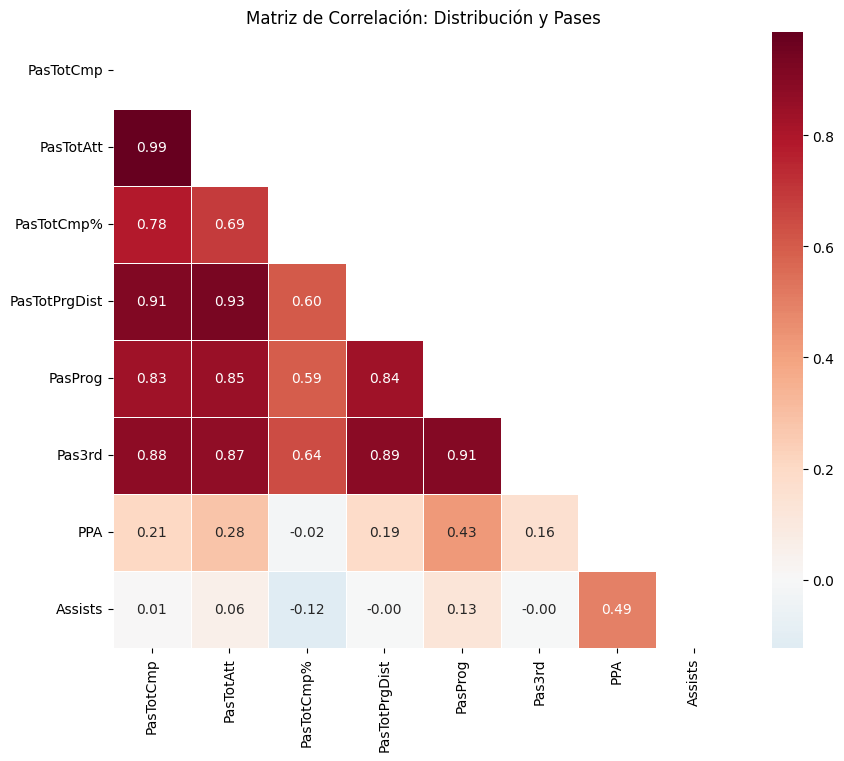

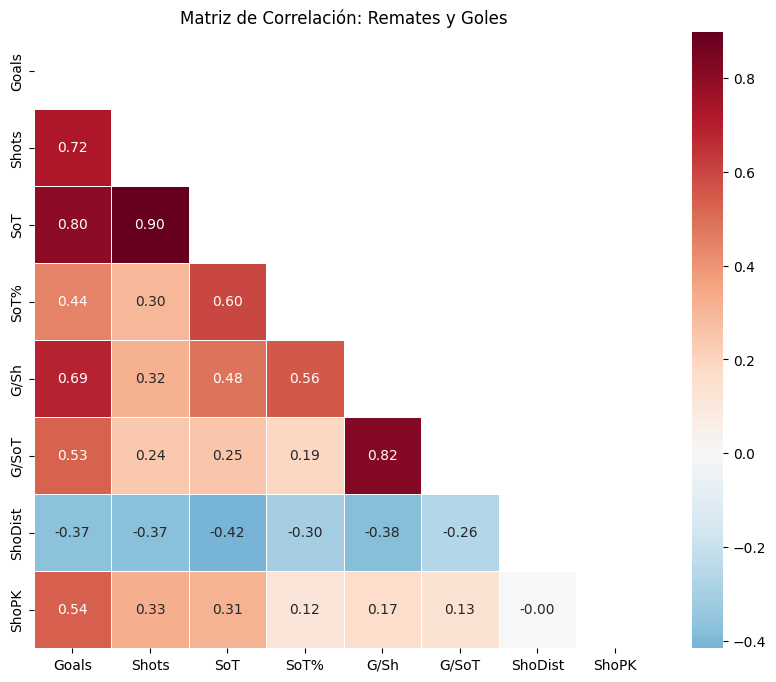

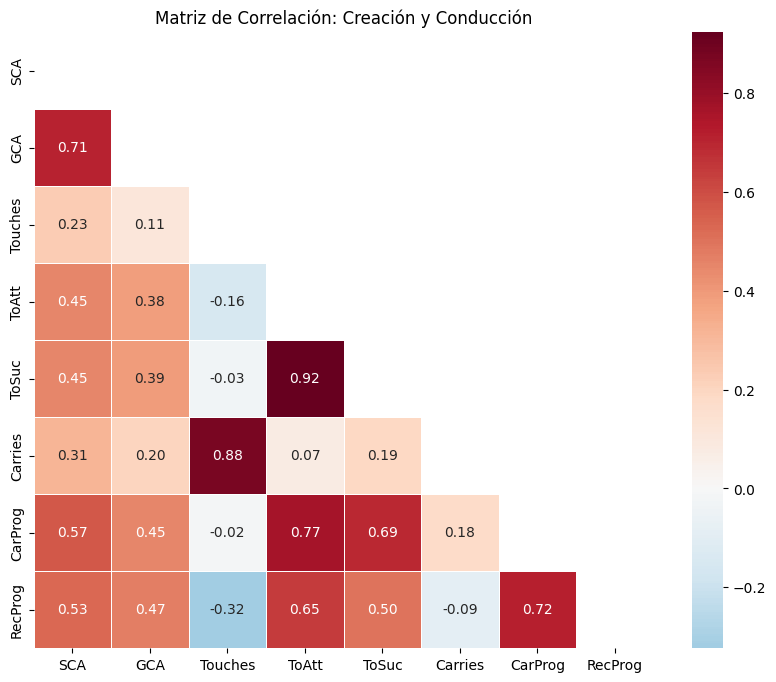

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definimos los grupos de interés (usando tus nombres de columnas)
grupos = {
    'Distribución y Pases': ['PasTotCmp', 'PasTotAtt', 'PasTotCmp%', 'PasTotPrgDist', 'PasProg', 'Pas3rd', 'PPA', 'Assists'],
    'Remates y Goles': ['Goals', 'Shots', 'SoT', 'SoT%', 'G/Sh', 'G/SoT', 'ShoDist', 'ShoPK'],
    'Creación y Conducción': ['SCA', 'GCA', 'Touches', 'ToAtt', 'ToSuc', 'Carries', 'CarProg', 'RecProg']
}

# Creamos un bucle para generar un gráfico por cada grupo
for titulo, columnas in grupos.items():
    # Solo tomamos las que existen en tu DF
    cols_existentes = [c for c in columnas if c in df.columns]

    if len(cols_existentes) > 1:
        plt.figure(figsize=(10, 8))
        corr = df[cols_existentes].corr()


        sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0, mask=mask, linewidths=.5)
        plt.title(f'Matriz de Correlación: {titulo}')
        plt.show()

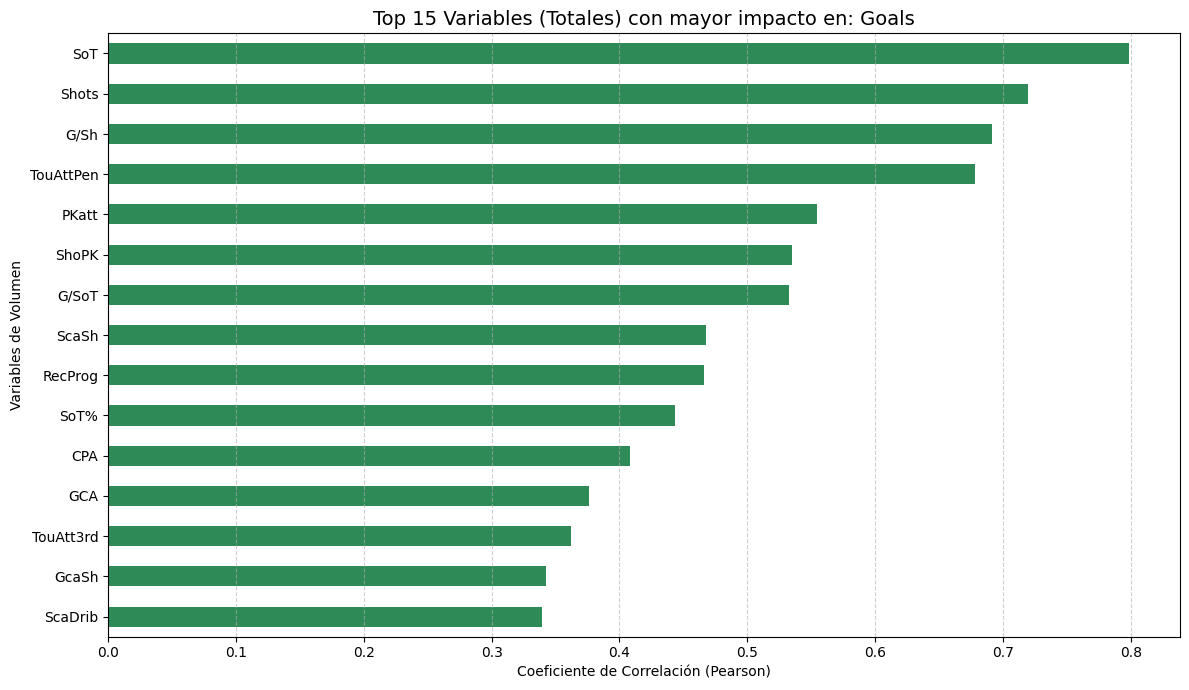

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos el objetivo
target = 'Goals'

# 2. Calculamos la matriz de correlación solo para números
corr_all = df.select_dtypes(include=[np.number]).corr()

# 3. Filtramos la serie de correlación del 'Target'
# Excluimos las que tengan '_90' en el nombre o sean la métrica de tiempo '90s'
correlaciones_target = corr_all[target]
correlaciones_target = correlaciones_target[
    ~correlaciones_target.index.str.contains('_90|90s')
]

# 4. Ordenamos y tomamos el Top 15 (excluyendo el propio 'Goals')
top_15_corr = correlaciones_target.sort_values(ascending=False)[1:16]

# 5. Graficamos
plt.figure(figsize=(12, 7))
top_15_corr.plot(kind='barh', color='seagreen') # Un verde tipo cancha queda bien

plt.title(f'Top 15 Variables (Totales) con mayor impacto en: {target}', fontsize=14)
plt.xlabel('Coeficiente de Correlación (Pearson)')
plt.ylabel('Variables de Volumen')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

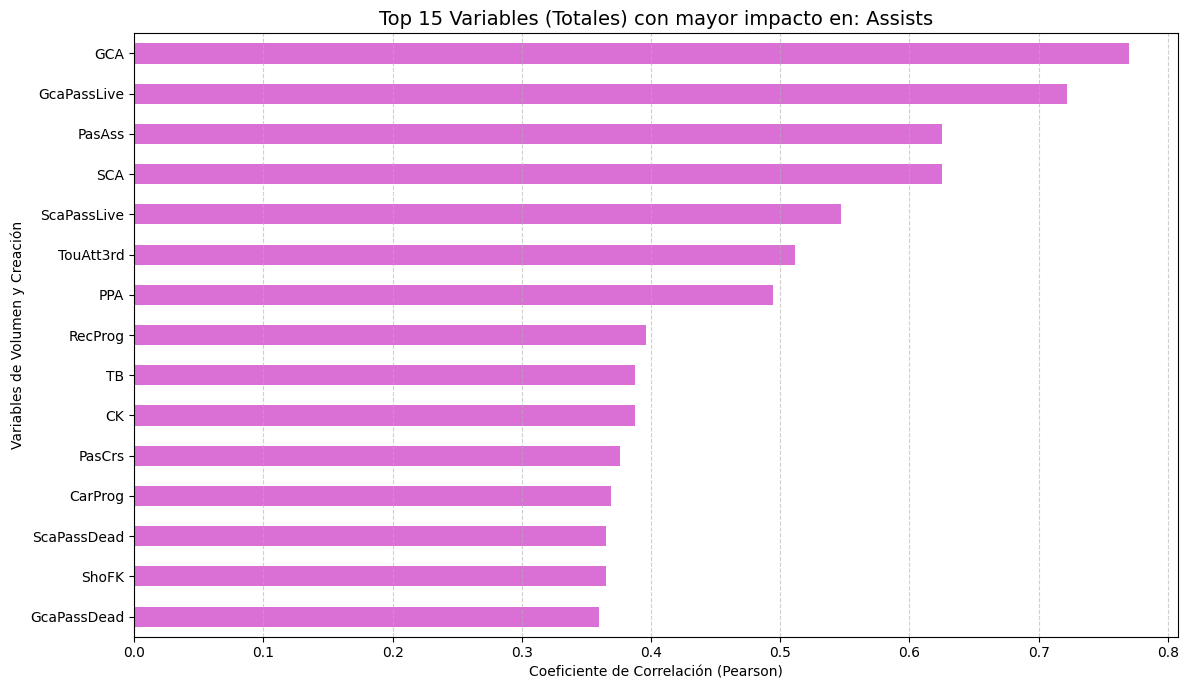

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos el nuevo objetivo: Asistencias
target_asistencias = 'Assists'

# 2. Calculamos la correlación solo para números
corr_all = df.select_dtypes(include=[np.number]).corr()

# 3. Filtramos la serie de correlación del 'Target'
# Seguimos excluyendo las proyectadas (_90) y las de tiempo (90s, Min, etc.)
correlaciones_asist = corr_all[target_asistencias]
correlaciones_asist = correlaciones_asist[
    ~correlaciones_asist.index.str.contains('_90|90s|Min|MP|Starts')
]

# 4. Ordenamos y tomamos el Top 15 (excluyendo la propia 'Assists')
top_15_asist = correlaciones_asist.sort_values(ascending=False)[1:16]

# 5. Graficamos con un color distinto para diferenciar del de Goles
plt.figure(figsize=(12, 7))
top_15_asist.plot(kind='barh', color='orchid') # Un tono púrpura/orquídea queda muy profesional

plt.title(f'Top 15 Variables (Totales) con mayor impacto en: {target_asistencias}', fontsize=14)
plt.xlabel('Coeficiente de Correlación (Pearson)')
plt.ylabel('Variables de Volumen y Creación')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()